<a href="https://colab.research.google.com/github/sinsley07/Tippy/blob/main/%E8%B3%87%E6%96%99%E5%BA%AB%E9%80%A3%E6%8E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install mysql-connector-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 58.1 MB/s eta 0:00:00


In [1]:
import pandas as pd

# 讀取 Excel
df = pd.read_excel("SHOP_DATA_ADVANCED_220_ROWS.xlsx")

# 顯示前幾筆資料
print(df.head())


      order_id customer_id customer_segment product_id product_name  \
0  ORD20240001       C1072          Regular       P114        Boots   
1  ORD20240002       C1085          Regular       P108        Socks   
2  ORD20240003       C1070        Returning       P106     Backpack   
3  ORD20240004       C1040              VIP       P111        Scarf   
4  ORD20240005       C1084          Regular       P104          Hat   

      category  sub_category              supplier  unit_price  unit_cost  \
0     Footwear  Winter Shoes       StepOne Trading       96.20      49.49   
1     Footwear         Socks       StepOne Trading        6.25       3.29   
2  Accessories          Bags  Urban Accessory Ltd.       42.35      16.80   
3  Accessories      Neckwear  Urban Accessory Ltd.       15.63       6.72   
4  Accessories      Headwear  Urban Accessory Ltd.       15.67       6.30   

   ...       city     campaign  sale_date    month customer_rating returned  \
0  ...     Chiayi  No Campaign 

In [5]:
import mysql.connector

conn = mysql.connector.connect(
    host="mysql-tippy.alwaysdata.net",  # AlwaysData 提供的主機位址
    user="tippy",                     # AlwaysData 帳號
    password="Ew20070707",                 # AlwaysData 密碼
    database="tippy_shop_data"                # 你建立的資料庫名稱
)

cursor = conn.cursor()

# 把 Excel 資料寫入 MySQL
for _, row in df.iterrows():
    cursor.execute(
        "INSERT INTO sales (product_name, category, price, quantity, sale_date) VALUES (%s, %s, %s, %s, %s)",
        tuple(row)
    )

conn.commit()
print("✅ Excel 資料已成功上傳到 MySQL！")


ProgrammingError: Not all parameters were used in the SQL statement

In [6]:
import mysql.connector
import pandas as pd

# 假設 Excel 已經讀入 df
df = pd.read_excel("SHOP_DATA_ADVANCED_220_ROWS.xlsx")

# 確保只保留需要的欄位
df = df[["product_name", "category", "price", "quantity", "sale_date"]]

conn = mysql.connector.connect(
    host="mysql-tippy.alwaysdata.net",
    user="tippy",
    password="Ew20070707",
    database="tippy_shop_data"
)
cursor = conn.cursor()

for _, row in df.iterrows():
    cursor.execute(
        "INSERT INTO sales (product_name, category, price, quantity, sale_date) VALUES (%s, %s, %s, %s, %s)",
        (row["product_name"], row["category"], row["price"], row["quantity"], row["sale_date"])
    )

conn.commit()
print("✅ Excel 資料已成功上傳到 MySQL！")


KeyError: "['price'] not in index"

In [7]:
print(df.columns)


Index(['order_id', 'customer_id', 'customer_segment', 'product_id',
       'product_name', 'category', 'sub_category', 'supplier', 'unit_price',
       'unit_cost', 'quantity', 'discount_rate', 'shipping_fee',
       'payment_method', 'sales_channel', 'city', 'campaign', 'sale_date',
       'month', 'customer_rating', 'returned', 'gross_sales',
       'discount_amount', 'net_sales', 'gross_profit'],
      dtype='object')


In [8]:
import mysql.connector
import pandas as pd

# 讀取 Excel
df = pd.read_excel("shop_data.xlsx")

# 確保只保留需要的欄位
df = df[["product_name", "category", "unit_price", "quantity", "sale_date"]]

# 連線到 AlwaysData MySQL
conn = mysql.connector.connect(
    host="mysql-tippy.alwaysdata.net",
    user="tippy",
    password="Ew20070707",
    database="tippy_shop_data"
)
cursor = conn.cursor()

# 插入資料
for _, row in df.iterrows():
    cursor.execute(
        "INSERT INTO sales (product_name, category, unit_price, quantity, sale_date) VALUES (%s, %s, %s, %s, %s)",
        (row["product_name"], row["category"], row["unit_price"], row["quantity"], row["sale_date"])
    )

conn.commit()
print("✅ Excel 資料已成功上傳到 MySQL！")


FileNotFoundError: [Errno 2] No such file or directory: 'shop_data.xlsx'

In [9]:
import os
print(os.listdir())  # 列出目前資料夾的檔案


['.config', 'SHOP_DATA_ADVANCED_220_ROWS.xlsx', '.ipynb_checkpoints', 'sample_data']


In [10]:
import pandas as pd

df = pd.read_excel("SHOP_DATA_ADVANCED_220_ROWS.xlsx")
print(df.head())       # 確認前幾筆資料
print(df.columns)      # 確認欄位名稱


      order_id customer_id customer_segment product_id product_name  \
0  ORD20240001       C1072          Regular       P114        Boots   
1  ORD20240002       C1085          Regular       P108        Socks   
2  ORD20240003       C1070        Returning       P106     Backpack   
3  ORD20240004       C1040              VIP       P111        Scarf   
4  ORD20240005       C1084          Regular       P104          Hat   

      category  sub_category              supplier  unit_price  unit_cost  \
0     Footwear  Winter Shoes       StepOne Trading       96.20      49.49   
1     Footwear         Socks       StepOne Trading        6.25       3.29   
2  Accessories          Bags  Urban Accessory Ltd.       42.35      16.80   
3  Accessories      Neckwear  Urban Accessory Ltd.       15.63       6.72   
4  Accessories      Headwear  Urban Accessory Ltd.       15.67       6.30   

   ...       city     campaign  sale_date    month customer_rating returned  \
0  ...     Chiayi  No Campaign 

In [11]:
import mysql.connector

conn = mysql.connector.connect(
    host="mysql-tippy.alwaysdata.net",
    user="tippy",        # AlwaysData 帳號
    password="Ew20070707",    # AlwaysData MySQL 密碼
    database="tippy_shop_data"   # 你建立的資料庫名稱
)
cursor = conn.cursor()
print("✅ 已成功連線至 AlwaysData MySQL！")


✅ 已成功連線至 AlwaysData MySQL！


In [13]:
import pandas as pd

# 讀取老師提供的 Excel 檔案
df = pd.read_excel("SHOP_DATA_ADVANCED_220_ROWS.xlsx")

# 檢查前幾筆資料與欄位名稱
print(df.head())
print(df.columns)


      order_id customer_id customer_segment product_id product_name  \
0  ORD20240001       C1072          Regular       P114        Boots   
1  ORD20240002       C1085          Regular       P108        Socks   
2  ORD20240003       C1070        Returning       P106     Backpack   
3  ORD20240004       C1040              VIP       P111        Scarf   
4  ORD20240005       C1084          Regular       P104          Hat   

      category  sub_category              supplier  unit_price  unit_cost  \
0     Footwear  Winter Shoes       StepOne Trading       96.20      49.49   
1     Footwear         Socks       StepOne Trading        6.25       3.29   
2  Accessories          Bags  Urban Accessory Ltd.       42.35      16.80   
3  Accessories      Neckwear  Urban Accessory Ltd.       15.63       6.72   
4  Accessories      Headwear  Urban Accessory Ltd.       15.67       6.30   

   ...       city     campaign  sale_date    month customer_rating returned  \
0  ...     Chiayi  No Campaign 

In [14]:
import mysql.connector

# 連線到 AlwaysData MySQL
conn = mysql.connector.connect(
    host="mysql-tippy.alwaysdata.net",
    user="tippy",        # AlwaysData 帳號
    password="Ew20070707",    # AlwaysData MySQL 密碼
    database="tippy_shop_data"   # 你建立的資料庫名稱
)
cursor = conn.cursor()

# 建立資料表（如果不存在）
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INT AUTO_INCREMENT PRIMARY KEY,
    product_name VARCHAR(50),
    category VARCHAR(30),
    unit_price DECIMAL(10,2),
    quantity INT,
    sale_date DATE
)
""")

print("✅ 已成功建立 sales 資料表！")


✅ 已成功建立 sales 資料表！


In [15]:
# 只保留需要的欄位
df = df[["product_name", "category", "unit_price", "quantity", "sale_date"]]

# 插入資料
for _, row in df.iterrows():
    cursor.execute(
        "INSERT INTO sales (product_name, category, unit_price, quantity, sale_date) VALUES (%s, %s, %s, %s, %s)",
        (row["product_name"], row["category"], row["unit_price"], row["quantity"], row["sale_date"])
    )

conn.commit()
print("✅ Excel 資料已成功匯入 MySQL！")


✅ Excel 資料已成功匯入 MySQL！


In [16]:
import mysql.connector
import pandas as pd

# 連線到 AlwaysData MySQL
conn = mysql.connector.connect(
    host="mysql-tippy.alwaysdata.net",
    user="tippy",
    password="Ew20070707",
    database="tippy_shop_data"
)

# 用 pandas 直接查詢全部資料
df = pd.read_sql("SELECT * FROM sales", conn)

print(df)          # 顯示所有資料
print(df.shape)    # 顯示資料筆數與欄位數


/tmp/ipykernel_1490/2730384491.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM sales", conn)


      id product_name     category  unit_price  quantity   sale_date
0      1        Boots     Footwear       96.20         2  2025-01-21
1      2        Socks     Footwear        6.25         2  2025-03-02
2      3     Backpack  Accessories       42.35         3  2025-01-02
3      4        Scarf  Accessories       15.63         4  2025-02-21
4      5          Hat  Accessories       15.67         2  2024-12-20
..   ...          ...          ...         ...       ...         ...
215  216        Boots     Footwear       91.09         1  2025-01-27
216  217       Gloves  Accessories       13.31         2  2024-08-02
217  218        Watch  Accessories      130.30         1  2025-01-14
218  219         Coat     Clothing      105.21         4  2024-07-24
219  220      Sandals     Footwear       24.36         4  2024-07-16

[220 rows x 6 columns]
(220, 6)


In [17]:
# 顯示所有列
pd.set_option("display.max_rows", None)

print(df)


      id product_name     category  unit_price  quantity   sale_date
0      1        Boots     Footwear       96.20         2  2025-01-21
1      2        Socks     Footwear        6.25         2  2025-03-02
2      3     Backpack  Accessories       42.35         3  2025-01-02
3      4        Scarf  Accessories       15.63         4  2025-02-21
4      5          Hat  Accessories       15.67         2  2024-12-20
5      6        Watch  Accessories      138.89         3  2024-11-01
6      7        Shoes     Footwear       63.25         3  2025-01-15
7      8     Sneakers     Footwear       72.05         4  2025-02-27
8      9      Sandals     Footwear       24.47         7  2024-11-28
9     10          Hat  Accessories       14.09         5  2025-02-04
10    11     Sneakers     Footwear       74.86         2  2025-02-10
11    12       Gloves  Accessories       12.96         4  2025-03-23
12    13     Sneakers     Footwear       71.35         7  2024-10-21
13    14         Coat     Clothing

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37559 (\N{CJK UNIFIED IDEOGRAPH-92B7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21806 (\N{CJK UNIFIED IDEOGRAPH-552E}) missing from font(s) DejaVu Sans.
  fig.canvas

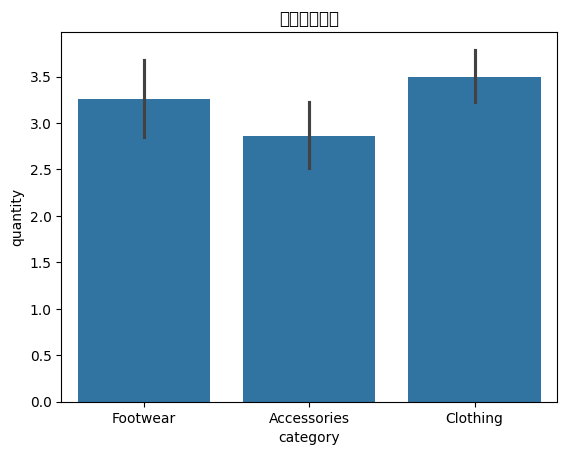

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37559 (\N{CJK UNIFIED IDEOGRAPH-92B7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21806 (\N{CJK UNIFIED IDEOGRAPH-552E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36264 (\N{CJK UNIFIED IDEOGRAPH-8DA8}) missing from font(s) DejaVu Sans.
  fig.canvas

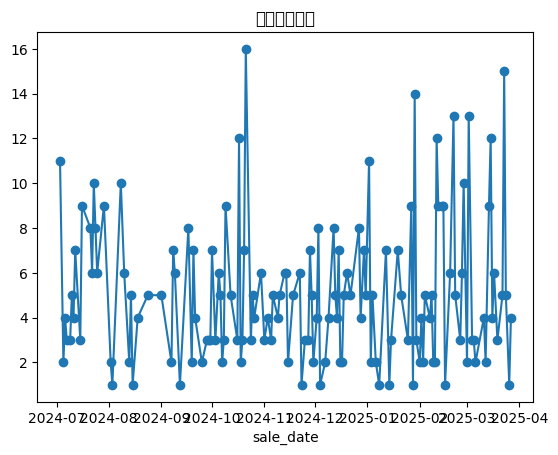

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37559 (\N{CJK UNIFIED IDEOGRAPH-92B7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21806 (\N{CJK UNIFIED IDEOGRAPH-552E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


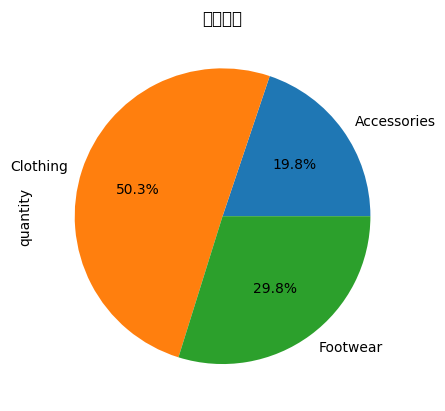

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20729 (\N{CJK UNIFIED IDEOGRAPH-50F9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33287 (\N{CJK UNIFIED IDEOGRAPH-8207}) missing from font(s) DejaVu Sans.
  fig.canvas

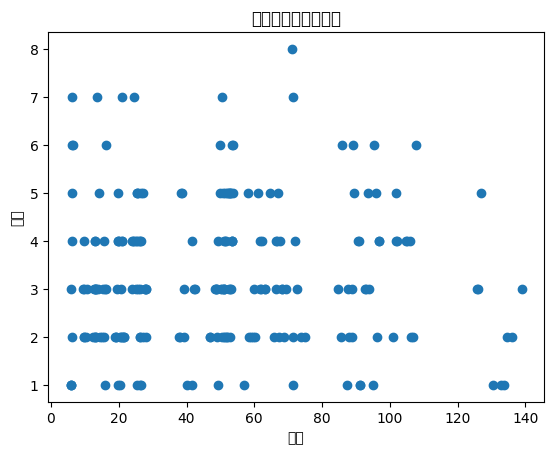

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 長條圖：各類別銷售量
sns.barplot(x="category", y="quantity", data=df)
plt.title("各類別銷售量")
plt.show()

# 折線圖：每日銷售趨勢
df.groupby("sale_date")["quantity"].sum().plot(kind="line", marker="o")
plt.title("每日銷售趨勢")
plt.show()

# 圓餅圖：各類別銷售比例
df.groupby("category")["quantity"].sum().plot(kind="pie", autopct="%1.1f%%")
plt.title("銷售比例")
plt.show()

# 散點圖：價格 vs 數量
plt.scatter(df["unit_price"], df["quantity"])
plt.xlabel("單價")
plt.ylabel("數量")
plt.title("價格與銷售數量關係")
plt.show()


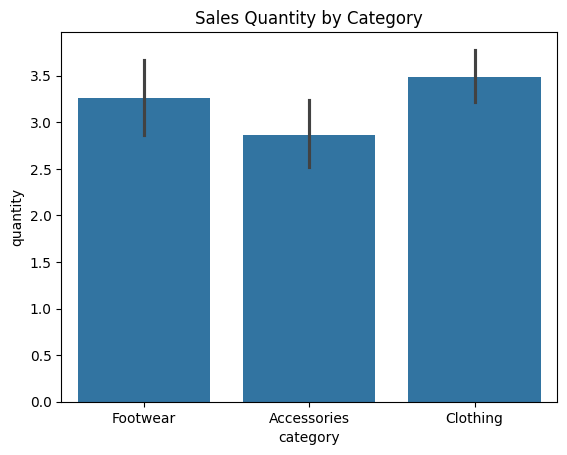

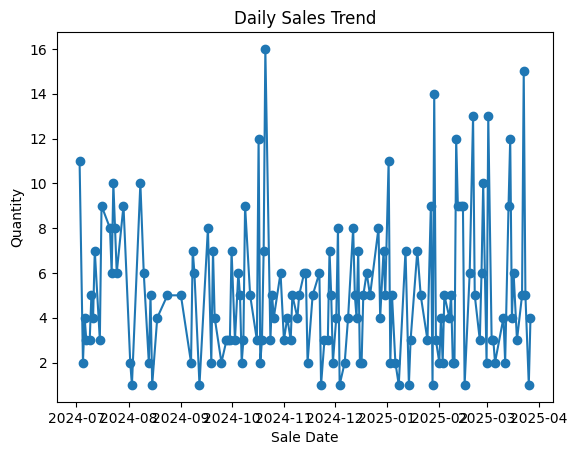

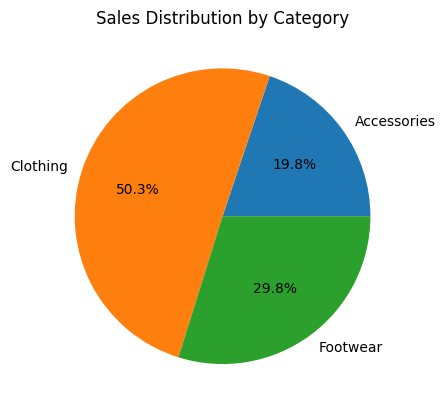

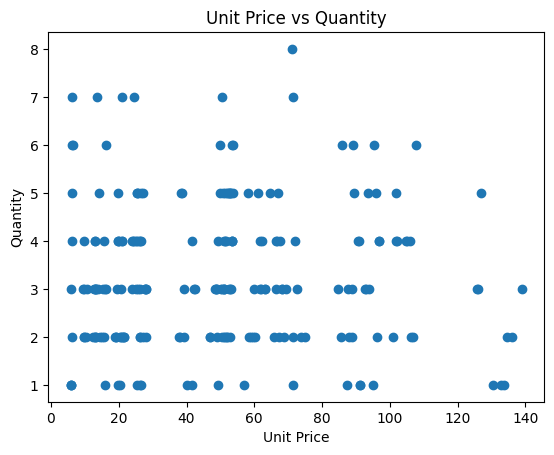

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar Chart: Sales Quantity by Category
sns.barplot(x="category", y="quantity", data=df)
plt.title("Sales Quantity by Category")
plt.show()

# Line Chart: Daily Sales Trend
df.groupby("sale_date")["quantity"].sum().plot(kind="line", marker="o")
plt.title("Daily Sales Trend")
plt.xlabel("Sale Date")
plt.ylabel("Quantity")
plt.show()

# Pie Chart: Sales Distribution by Category
df.groupby("category")["quantity"].sum().plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales Distribution by Category")
plt.ylabel("")  # 移除 y 標籤避免重疊
plt.show()

# Scatter Plot: Unit Price vs Quantity
plt.scatter(df["unit_price"], df["quantity"])
plt.xlabel("Unit Price")
plt.ylabel("Quantity")
plt.title("Unit Price vs Quantity")
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

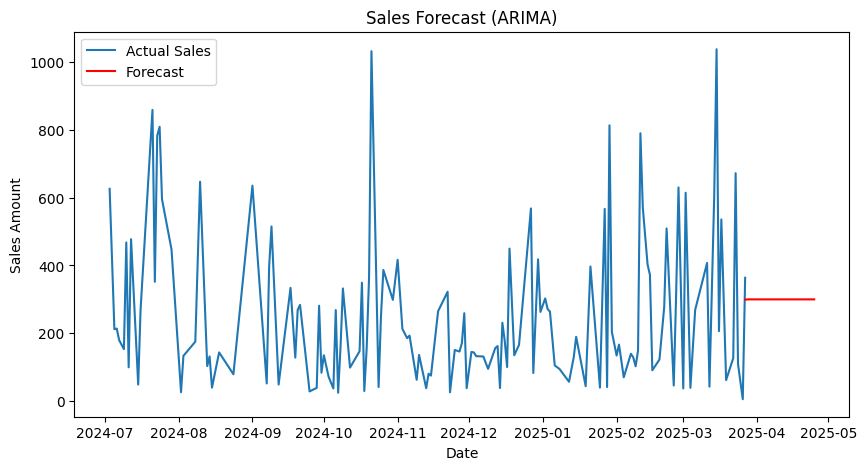

In [21]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 建立銷售額欄位
df["sales_amount"] = df["unit_price"] * df["quantity"]

# 按日期聚合
daily_sales = df.groupby("sale_date")["sales_amount"].sum()

# 建立 ARIMA 模型
model = ARIMA(daily_sales, order=(1,1,1))
model_fit = model.fit()

# 預測未來 30 天
forecast = model_fit.forecast(steps=30)

# 畫圖比較
plt.figure(figsize=(10,5))
plt.plot(daily_sales.index, daily_sales, label="Actual Sales")
plt.plot(pd.date_range(daily_sales.index[-1], periods=30, freq="D"), forecast, label="Forecast", color="red")
plt.title("Sales Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.legend()
plt.show()
